In [27]:
import pathlib
import typing

import lightning.pytorch
import matplotlib.pyplot as plt
import rasterio
import torch
import torch.nn
import torch.utils.data
import torchgeo.datamodules
import torchgeo.datasets
import torchgeo.samplers
import torchgeo.trainers
import torchgeo.transforms
import torchvision.models

# Data Loading
This notebook uses the [Earth Surface Water Dataset](https://zenodo.org/records/5205674), a collection of six-band Sentinel 2 images accompanied by water body masks.

| Data band | sentinel band | res | wavelength | desc                             |
|-----------|---------------|-----|------------|----------------------------------|
| 1         | 2             | 10  | 490        | B                                |
| 2         | 3             | 10  | 560        | G                                |
| 3         | 4             | 10  | 665        | R                                |
| 4         | 8             | 10  | 842        | Visible and Near Infrared (VNIR) |
| 5         | 11            | 20  | 1610       | Short Wave Infrared (SWIR)       |
| 6         | 12            | 20  | 2190       | Short Wave Infrared (SWIR)       |

In [2]:
root = pathlib.Path('./dset-s2')

In [3]:
train_img_path = root / 'tra_scene'
train_msk_path = root / 'tra_truth'

valid_img_path = root / 'val_scene'
valid_msk_path = root / 'val_truth'

In [4]:
# TOSELF: I could use a pattern like this to list files during the data parsing step.
train_imgs = list((root / 'tra_scene').glob('*.tif'))
train_msks = list((root / 'tra_truth').glob('*.tif'))

In [5]:
# Ensure that the images and masks are aligned lexicographically so that they can be accessed using a single, common index.
train_imgs.sort()
train_msks.sort()

# Data Exploration

In [6]:
img_idx = 0

In [7]:
img_src: rasterio.io.DatasetReader
msk_src: rasterio.io.DatasetReader
with rasterio.open(train_imgs[img_idx]) as img_src:
    img = img_src.read()
with rasterio.open(train_msks[img_idx]) as msk_src:
    msk = msk_src.read()

In [8]:
# TOSELF: The images and masks do not need to be square.
img.shape

(6, 764, 868)

In [9]:
msk.shape

(1, 764, 868)

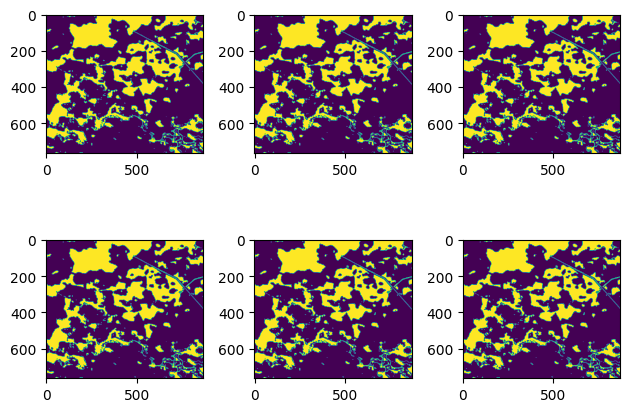

In [10]:
fig, axes = plt.subplots(2, 3)
for bnd_idx, ax in enumerate(axes.ravel()):
    # Convert the raw satellite measurements to actual pixel values.
    ax.imshow(msk[0, :, :] * 1e-5)
plt.tight_layout()

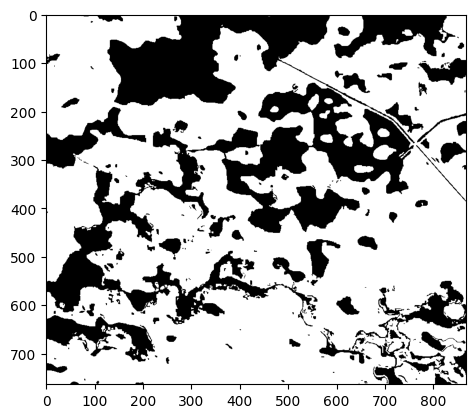

In [11]:
plt.imshow(msk[0, :, :], cmap='binary')

# Step 1 - Construct the image and mask datasets.

In [12]:
def scale_image(item: dict):
    # NOTE: A sample from the dataset is a dict in the form of:
    # {
    # "crs":
    # "bbox":
    # "image":
    # }
    # if the dataset contains masks the image key is replaced with mask
    item['image'] *= 1e-5
    return item


# TOSELF: Are the 20 m bands resampled to 10 m?
train_imgs = torchgeo.datasets.RasterDataset(train_img_path.absolute().as_posix(),
                                             # NOTE: The CRS must be specified because the images use various projections, and should thus be normalized.
                                             crs="EPSG:3395",
                                             # NOTE: The pixel size must be specified for the same reason as above.
                                             # TOSELF: Is this really required?
                                             res=10,
                                             transforms=scale_image)
train_msks = torchgeo.datasets.RasterDataset(train_msk_path.absolute().as_posix(), crs="EPSG:3395")
# Specify that the data contains masks.
train_msks.is_image = False

valid_imgs = torchgeo.datasets.RasterDataset(valid_img_path.absolute().as_posix(),
                                             # NOTE: The CRS must be specified because the images use various projections, and should thus be normalized.
                                             crs="EPSG:3395",
                                             # NOTE: The pixel size must be specified for the same reason as above.
                                             # TOSELF: Is this really required?
                                             res=10,
                                             transforms=scale_image)
valid_msks = torchgeo.datasets.RasterDataset(valid_msk_path.absolute().as_posix(), crs="EPSG:3395")
# Specify that the data contains masks.
valid_msks.is_image = False

# Step 2 - Construct the corresponding sampler.

In [13]:
# TOSELF: Explore the various samplers.
train_sampler = torchgeo.samplers.RandomGeoSampler(train_imgs,
                                                   size=512,
                                                   # TOSELF: How to determine the optimal value of the length?
                                                   length=256)
valid_sampler = torchgeo.samplers.RandomGeoSampler(valid_imgs,
                                                   size=512,
                                                   # TOSELF: How to determine the optimal value of the length?
                                                   length=128)

# Step 3 - Intersect the datasets.

In [14]:
# TOSELF: The images do not need to be merged with the corresponding masks.
# TOSELF: I could use a pattern like this merge rasters during the data parsing step.
train_data = train_imgs & train_msks
valid_data = valid_imgs & valid_msks

# Step 4 - Construct the corresponding loader.

In [15]:
# TOSELF: Explore the various loaders.
train_loader = torch.utils.data.DataLoader(train_data,
                                           sampler=train_sampler,
                                           # TOSELF: How does this parameter compare to the sampler length?
                                           batch_size=8,
                                           collate_fn=torchgeo.datasets.stack_samples)
valid_loader = torch.utils.data.DataLoader(valid_data,
                                           sampler=valid_sampler,
                                           # TOSELF: How does this parameter compare to the sampler length?
                                           batch_size=8,
                                           collate_fn=torchgeo.datasets.stack_samples)

## Data Exploration

In [16]:
# TODO: Clean up this cell.
def plot_imgs(images: typing.Iterable, axs: typing.Iterable, chnls: typing.List[int] = [2, 1, 0], bright: float = 0.1):
    for img, ax in zip(images, axs):
        arr = torch.clamp(bright * img, min=0, max=1).numpy()
        rgb = arr.transpose(1, 2, 0)[:, :, chnls]
        ax.imshow(rgb)
        ax.axis('off')


def plot_msks(masks: typing.Iterable, axs: typing.Iterable):
    for mask, ax in zip(masks, axs):
        ax.imshow(mask.squeeze().numpy(), cmap='Blues')
        ax.axis('off')


def plot_batch(batch: dict, bright: float = 3., cols: int = 4, width: int = 5, chnls: typing.List[int] = [2, 1, 0]):

    # Get the samples and the number of items in the batch
    samples = torchgeo.datasets.unbind_samples(batch.copy())

    # if batch contains images and masks, the number of images will be doubled
    n = 2 * len(samples) if ('image' in batch) and ('mask' in batch) else len(samples)

    # calculate the number of rows in the grid
    rows = n // cols + (1 if n % cols != 0 else 0)

    # create a grid
    _, axs = plt.subplots(rows, cols, figsize=(cols * width, rows * width))

    if ('image' in batch) and ('mask' in batch):
        # plot the images on the even axis
        plot_imgs(images=map(lambda x: x['image'], samples),
                  axs=axs.reshape(-1)[::2],
                  chnls=chnls,
                  bright=bright)  #type: ignore

        # plot the masks on the odd axis
        plot_msks(masks=map(lambda x: x['mask'], samples), axs=axs.reshape(-1)[1::2])  #type: ignore

    else:

        if 'image' in batch:
            plot_imgs(images=map(lambda x: x['image'], samples),
                      axs=axs.reshape(-1),
                      chnls=chnls,
                      bright=bright)  #type: ignore

        elif 'mask' in batch:
            plot_msks(masks=map(lambda x: x['mask'], samples), axs=axs.reshape(-1))  #type: ignore

In [17]:
# batch = next(iter(train_loader))
# plot_batch(batch)

# Step 5. Normalize the merged dataset.

# Step 6. Enrich the image dataset with various spectral index maps.

In [18]:
# TOSELF: Explore the various transforms.
# TOSELF: I could use a pattern like this to augment the training data.
ndwi = torchgeo.transforms.AppendNDWI(1, 3)
ndvi = torchgeo.transforms.AppendNDVI(3, 2)
append_spectral_indices = torch.nn.Sequential(ndvi, ndwi)

In [19]:
# batch["image"] = append_spectral_indices(batch["image"])
# batch["image"].shape

# Step 7 - Construct the model.


In [20]:
model = torchvision.models.segmentation.deeplabv3_resnet50(num_classes=2)
# Increase the number of input channels in the first convolutional layer of the backbone with one that accepts the augmented images.
backbone = model.get_submodule('backbone')
convolve = torch.nn.modules.conv.Conv2d(in_channels=8,
                                        out_channels=64,
                                        kernel_size=(7, 7),
                                        stride=(2, 2),
                                        padding=(3, 3),
                                        bias=False)
backbone.register_module('conv1', convolve)

# Step 8 - Define the training loop.

In [21]:
def train_loop(epochs: int,
               train_dl: torch.utils.data.DataLoader,
               val_dl: typing.Optional[torch.utils.data.DataLoader],
               model: torch.nn.Module,
               loss_fn: typing.Callable,
               optimizer: torch.optim.Optimizer,
               acc_fns: typing.Optional[typing.List] = None,
               batch_tfms: typing.Optional[typing.Callable] = None):
    # size = len(dataloader.dataset)
    cuda_model = model.cuda()

    for epoch in range(epochs):
        accum_loss = 0
        for batch in train_dl:

            if batch_tfms is not None:
                batch['image'] = batch_tfms(batch['image'])

            X = batch['image'].cuda()
            y = batch['mask'].type(torch.long).cuda()
            pred = cuda_model(X)['out']
            loss = loss_fn(pred, y)

            # BackProp
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # update the accum loss
            accum_loss += float(loss) / len(train_dl)

        # Testing against the validation dataset
        if acc_fns is not None and val_dl is not None:
            # reset the accuracies metrics
            acc = [0.] * len(acc_fns)

            with torch.no_grad():
                for batch in val_dl:

                    if batch_tfms is not None:
                        batch['image'] = batch_tfms(batch['image'])

                    X = batch['image'].type(torch.float32).cuda()
                    y = batch['mask'].type(torch.long).cuda()

                    pred = cuda_model(X)['out']

                    for i, acc_fn in enumerate(acc_fns):
                        acc[i] = float(acc[i] + acc_fn(pred, y) / len(val_dl))

            # at the end of the epoch, print the errors, etc.
            print(f'Epoch {epoch}: Train Loss={accum_loss:.5f} - Accs={[round(a, 3) for a in acc]}')
        else:

            print(f'Epoch {epoch}: Train Loss={accum_loss:.5f}')

# Step 9 - Metrics

In [22]:
def oa(pred, y):
    flat_y = y.squeeze()
    flat_pred = pred.argmax(dim=1)
    acc = torch.count_nonzero(flat_y == flat_pred) / torch.numel(flat_y)
    return acc


def iou(pred, y):
    flat_y = y.cpu().numpy().squeeze()
    flat_pred = pred.argmax(dim=1).detach().cpu().numpy()
    return torch.metrics.jaccard_score(flat_y.reshape(-1), flat_pred.reshape(-1), zero_division=1.)


def loss(p, t):
    return torch.nn.functional.cross_entropy(p, t.squeeze())

# Step 10 - Train

In [23]:
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)
# train_loop(5, train_loader, valid_loader, model, loss, optimizer, acc_fns=[oa, iou], batch_tfms=append_spectral_indices)

In [29]:
"""
# TODO
    1. Create a dataset similar to `torchgeo.datasets.InriaAerialImageLabeling`.
    2. Create a datamodule similar to `torchgeo.datamodules.InriaAerialImageLabelingDataModule`.
    3. Create a task similar to torchgeo.trainers.SemanticSegmentationTask`.
    4. Create a trainer similar to `lightning`pytorch.Trainer`.
"""

datamodule = torchgeo.datamodules.InriaAerialImageLabelingDataModule(root="...", num_workers=6)

task = torchgeo.trainers.SemanticSegmentationTask(model="unet",
                                                  backbone="resnet50",
                                                  weights=True,
                                                  in_channels=3,
                                                  num_classes=2,
                                                  loss="ce",
                                                  ignore_index=None,
                                                  lr=0.1,
                                                  patience=6)

trainer = lightning.pytorch.Trainer()
trainer.fit(model=task, datamodule=datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


RuntimeError: Dataset not found in `root=...` either specify a different `root` directory or download the dataset to this directory